# Sessao 0 - 19/08/2026

## Ecosistema Geoespacial

# Future Tech Leaders Brasil

## Space Tech Bootcamp

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import os 


In [2]:
os.getcwd()

'/Users/macuser/Documents/UN/ebook/fundamentals_gis_rs/week0'

In [3]:
# lets read our csv with the location of everyone
df = pd.read_excel('data/NOS-FTL-Brasil.xlsx')

df.head()

,ID,"De onde você é? (Escreva como: Cidade/SG. exemplo: Pindamonhangaba/SP . Tarauca/AC , catole do rocha/PB)\n\n"
0,1,Fortaleza-CE
1,2,RECIFE/PE
2,3,Limeira/SP
3,4,Curitiba - Paraná
4,5,Viamão/RS


## Limpeza de dados

Aquilo que todo cientista de dados ama.

## ETL  - Extract,  Transform and Load

In [4]:
df.columns

Index(['ID', 'De onde você é? (Escreva como: Cidade/SG.  exemplo: Pindamonhangaba/SP . Tarauca/AC , catole do rocha/PB)\n\n'], dtype='str')

In [5]:
place= df.columns[1]
df.rename(columns={place:'lugar'},inplace=True)

In [6]:
df['lugar'].unique()

<StringArray>
[            'Fortaleza-CE',                'RECIFE/PE',
               'Limeira/SP',       'Curitiba - Paraná ',
                'Viamão/RS',                'Recife/PE',
                'Fortaleza',                 'Betim/MG',
   'São José dos Campos/SP',                'Toledo/PR',
            'Santarém/Pará',          'Santarém - Pará',
                  'Ijuí/RS',            'Fortaleza, ce',
               'Niterói/RJ',              'Gravataí/RS',
         'Florianópolis/SC',               'Pinhais/PR',
               'Goiânia/GO', 'Campos dos Goytacazes/RJ',
      'Rio de Janeiro / RJ',          'Porto velho/RO ',
        'Campina Grande/PB',                 'Belém/PA',
              'Brasília/DF',      'Lauro de Freitas/BA',
          'Passa Quatro/MG',       'Glória do Goitá/PE',
               'Betim - MG',            'Araraquara/SP',
              'Floresta/PR',             'Rio Claro/SP',
   'Presidente Prudente/SP',           'Santa Maria/RS',
              'Sa

## Geocodificação

Agora vamos transformar cada `lugar` (texto livre, do jeito que cada pessoa preencheu no formulário) em coordenadas (latitude, longitude), usando a API pública do [Nominatim](https://nominatim.org/) (OpenStreetMap).

Como o texto livre tem bastante variação — separadores diferentes (`/`, `-`, `,`), estado abreviado vs. nome completo, prefixos tipo "Sou de..." — fazemos só uma limpeza leve antes de geocodificar. Não tentamos separar cidade/estado manualmente: casos como `"Minas - Pouso Alegre"` (ordem invertida!) tornariam isso frágil. Em vez disso, mandamos a string inteira para o Nominatim, que já é bom em interpretar texto livre — e na prática ele resolveu até esse caso invertido corretamente.

In [7]:
import re

def clean_place(raw: str) -> str:
    s = raw.strip()
    s = re.sub(r'(?i)^sou de\s+', '', s)   # tira prefixos tipo "Sou de Sobral/CE"
    s = re.sub(r'\s+', ' ', s)              # espaços duplicados
    s = s.strip(' -,/')                     # separadores soltos na ponta
    return s

df['lugar_limpo'] = df['lugar'].apply(clean_place)
df[['lugar', 'lugar_limpo']].drop_duplicates().head(10)

,lugar,lugar_limpo
0,Fortaleza-CE,Fortaleza-CE
1,RECIFE/PE,RECIFE/PE
2,Limeira/SP,Limeira/SP
3,Curitiba - Paraná,Curitiba - Paraná
4,Viamão/RS,Viamão/RS
5,Recife/PE,Recife/PE
6,Fortaleza,Fortaleza
7,Betim/MG,Betim/MG
8,São José dos Campos/SP,São José dos Campos/SP
9,Toledo/PR,Toledo/PR


In [8]:
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

CACHE_PATH = Path('data/geocoded_cache.csv')

if CACHE_PATH.exists():
    # já geocodificamos antes -- evita bater na API do Nominatim de novo
    cache = pd.read_csv(CACHE_PATH)
else:
    # user_agent é obrigatório pela política de uso do Nominatim -- identifica quem está chamando
    geolocator = Nominatim(user_agent='ftl-brasil-spacetech-bootcamp-week0', timeout=10)
    # 1 requisição/segundo é o limite do serviço público; swallow_exceptions evita que uma falha derrube o loop inteiro
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, error_wait_seconds=5,
                           max_retries=2, swallow_exceptions=True)

    unique_places = df[['lugar_limpo']].drop_duplicates().reset_index(drop=True)
    unique_places['location'] = unique_places['lugar_limpo'].apply(lambda p: geocode(p, country_codes='br'))
    unique_places['lat'] = unique_places['location'].apply(lambda loc: loc.latitude if loc else None)
    unique_places['lon'] = unique_places['location'].apply(lambda loc: loc.longitude if loc else None)
    unique_places['matched_address'] = unique_places['location'].apply(lambda loc: loc.address if loc else None)

    cache = unique_places[['lugar_limpo', 'lat', 'lon', 'matched_address']]
    cache.to_csv(CACHE_PATH, index=False)

df = df.merge(cache, on='lugar_limpo', how='left')

nao_geocodificados = df[df['lat'].isna()]
print(f"{len(nao_geocodificados)} de {len(df)} linhas não foram geocodificadas")
nao_geocodificados

0 de 57 linhas não foram geocodificadas


,ID,lugar,lugar_limpo,lat,lon,matched_address


In [9]:
gdf = gpd.GeoDataFrame(
    df.dropna(subset=['lat', 'lon']),
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326',
)
gdf.head()

,ID,lugar,lugar_limpo,lat,lon,matched_address,geometry
0,1,Fortaleza-CE,Fortaleza-CE,-3.793217,-38.528036,"Fortaleza, Ceará, Região Nordeste, Brasil",POINT (-38.52804 -3.79322)
1,2,RECIFE/PE,RECIFE/PE,-8.058493,-34.884819,"Recife, Pernambuco, Região Nordeste, Brasil",POINT (-34.88482 -8.05849)
2,3,Limeira/SP,Limeira/SP,-22.561507,-47.401766,"Limeira, São Paulo, Região Sudeste, Brasil",POINT (-47.40177 -22.56151)
3,4,Curitiba - Paraná,Curitiba - Paraná,-25.429596,-49.271272,"Curitiba, Paraná, Região Sul, Brasil",POINT (-49.27127 -25.4296)
4,5,Viamão/RS,Viamão/RS,-30.081934,-51.026193,"Viamão, Rio Grande do Sul, Região Sul, Brasil",POINT (-51.02619 -30.08193)


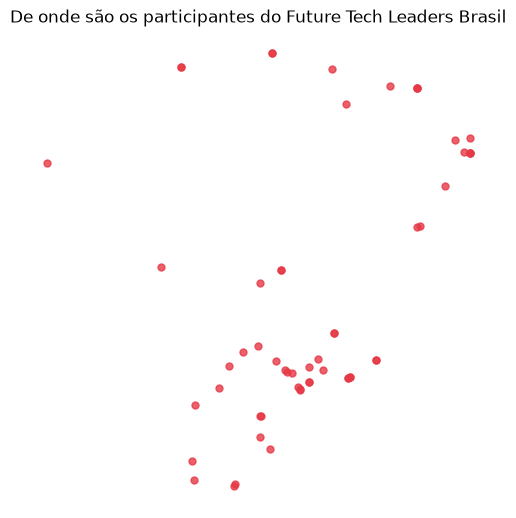

In [10]:
fig, ax = plt.subplots(figsize=(6, 7))
gdf.plot(ax=ax, markersize=25, color='#e63946', alpha=0.8)
ax.set_title('De onde são os participantes do Future Tech Leaders Brasil')
ax.set_axis_off()
plt.show()